# Conversion from coordinates to Lat, Lon

In [1]:
import numpy as np
from typing import Tuple
from pyproj import CRS, Transformer
import matplotlib.pyplot as plt

### 1. Initialising Georeferencing information and spatial domain dimensions.

In [2]:
# Original radar projection
PROJ_WKT = """
PROJCS["unknown",GEOGCS["unknown",DATUM["unknown",SPHEROID["unknown",6378137,298.252840776245]],
PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],
PROJECTION["Polar_Stereographic"],PARAMETER["latitude_of_origin",45],
PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],
UNIT["metre",1],AXIS["Easting",SOUTH],AXIS["Northing",SOUTH]]
"""

# Coordinate projection info
GEOTRANSFORM = (
    -619652.0953618084, # initial x0 starting point
    1000.0,             # x step (move forward by ~1000)
    -3526818.459196719, # initial y0 starting point 
    -999.9999999999997, # y step (move forward by ~1000)
)

# Array dimension
DOMAIN_DIMS = (
    1536, # Spatial domain (amount of pixel on the y axis)
    1536, # Spatial domain (amount of pixel on the x axis)
)

### 2. Collect Lat, Lon fields from coordinates.

In [3]:
def get_spatial_coords_arrays(
        x0: float,
        y0: float,
        x_step: float,
        y_step: float,
        width: int,
        height: int,
        ) -> Tuple[np.ndarray, np.ndarray]:
    """
    Convert a 2D array from the original projection to lat/lon coordinates.
    Args:
        x0: (float): initial x coords starting point.
        y0: (float): initial y coords starting point.
        x_step: (float): x step.
        y_step: (float): y step.
        width: (int) amount of pixels.
        height: (int) amount of pixels.
    Return:
        (x_coords, y_coords,) (1D np.ndarrays)
        (lon, lat) (2D np.ndarray)
    """
    # Init grid coords
    x_coords = x0 + np.arange(width) * x_step
    y_coords = y0 + np.arange(height) * y_step

    # Transform grid coords to lat/lon
    xx, yy    = np.meshgrid(x_coords, y_coords)
    crs_src   = CRS.from_wkt(PROJ_WKT)
    crs_dst   = CRS.from_epsg(4326)  
    to_latlon = Transformer.from_crs(crs_src, crs_dst, always_xy=True)
    lon, lat  = to_latlon.transform(xx, yy)

    return x_coords, y_coords, lon, lat


### 3. Display coordinates boundaries

In [4]:
x0, x_step, y0, y_step = GEOTRANSFORM
width, height          = DOMAIN_DIMS

x_coords, y_coords, lon, lat = \
    get_spatial_coords_arrays(x0, y0, x_step, y_step, width, height)


print(
    f"lon min:\t{lon.min():.04f}\n"+\
    f"lon max:\t{lon.max():.04f}\n"+\
    f"lat min:\t{lat.min():.04f}\n"+\
    f"lat max:\t{lat.max():.04f}"
)
print(
    f"x_coords min:\t{x_coords.min():.04f}\n"+\
    f"x_coords max:\t{x_coords.max():.04f}\n"+\
    f"y_coords min:\t{y_coords.min():.04f}\n"+\
    f"y_coords max:\t{y_coords.max():.04f}"
)

lon min:	-9.9650
lon max:	14.5495
lat min:	39.4779
lat max:	54.1840
x_coords min:	-619652.0954
x_coords max:	915347.9046
y_coords min:	-5061818.4592
y_coords max:	-3526818.4592


### 4. Plot

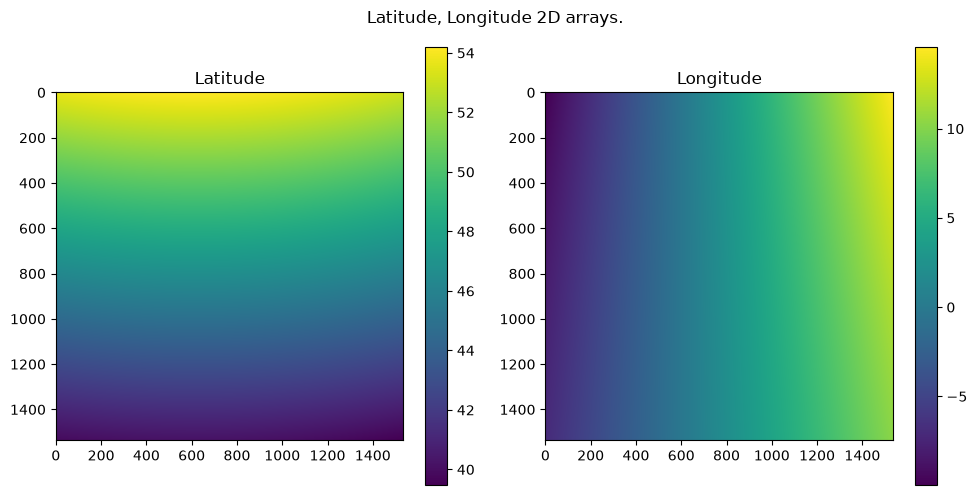

In [ ]:
_, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].set_title("Latitude")
lat_p=axs[0].imshow(lat)
plt.colorbar(lat_p)

axs[1].set_title("Longitude")
lon_p=axs[1].imshow(lon)
plt.colorbar(lon_p)
plt.suptitle("Latitude, Longitude 2D arrays.")
plt.tight_layout()
plt.show()

### 5. Fix `CRS_WKT` with Bounding Box

Moving from WKT v1 to v2 to be [mlcast-validator](https://github.com/mlcast-community/mlcast-dataset-validator) compliant.

Requires a GDAL build `pip install gdal` or corresponding wheel version.

In [ ]:
from osgeo import osr, ogr

# Original radar projection
# V1 without BBOX information 
PROJ_WKT_V1 = """
PROJCS["unknown",GEOGCS["unknown",DATUM["unknown",SPHEROID["unknown",6378137,298.252840776245]],
PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],
PROJECTION["Polar_Stereographic"],PARAMETER["latitude_of_origin",45],
PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],
UNIT["metre",1],AXIS["Easting",SOUTH],AXIS["Northing",SOUTH]],BBOX[39.477880507122855, -9.964999999999996, 54.18403098825441, 14.54948729204824]]
"""

# Corresponding V2 version to be mlcast-validator compliant.
PROJ_WKT_V2 = """
PROJCRS["unknown",
    BASEGEOGCRS["unknown",
        DATUM["unknown",
            ELLIPSOID["unknown",6378137,298.252840776245,
                LENGTHUNIT["metre",1]],
            ID["EPSG",6326]],
        PRIMEM["Greenwich",0,
            ANGLEUNIT["degree",0.0174532925199433]],
        ID["EPSG",4326]],
    CONVERSION["Polar Stereographic (variant B)",
        METHOD["Polar Stereographic (variant B)",
            ID["EPSG",9829]],
        PARAMETER["Latitude of standard parallel",45,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8832]],
        PARAMETER["Longitude of origin",0,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8833]],
        PARAMETER["False easting",0,
            LENGTHUNIT["metre",1],
            ID["EPSG",8806]],
        PARAMETER["False northing",0,
            LENGTHUNIT["metre",1],
            ID["EPSG",8807]]],
    CS[Cartesian,2],
        AXIS["Easting",south,
            ORDER[1],
            LENGTHUNIT["metre",1]],
        AXIS["Northing",south,
            ORDER[2],
            LENGTHUNIT["metre",1]],
    USAGE[
        SCOPE["Custom radar projection."],
        AREA["Region north of 45°N."],
        BBOX[39.477880507122855, -9.964999999999996, 54.18403098825441, 14.54948729204824]
    ]
]
"""

# If gdal installed execute to validate.
srs = osr.SpatialReference()
result = srs.SetFromUserInput(PROJ_WKT)
validation_code = srs.Validate()
if validation_code == 0:
    print("Valid CRS")
else:
    print(f"Invalid CRS: Validate() returned {validation_code}")